# EDA

In [1]:
# Packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read data
df = pd.read_csv("/Users/murphy.chen/Desktop/data1030final_project/data/Cleaned/cleaned_car_data.csv")

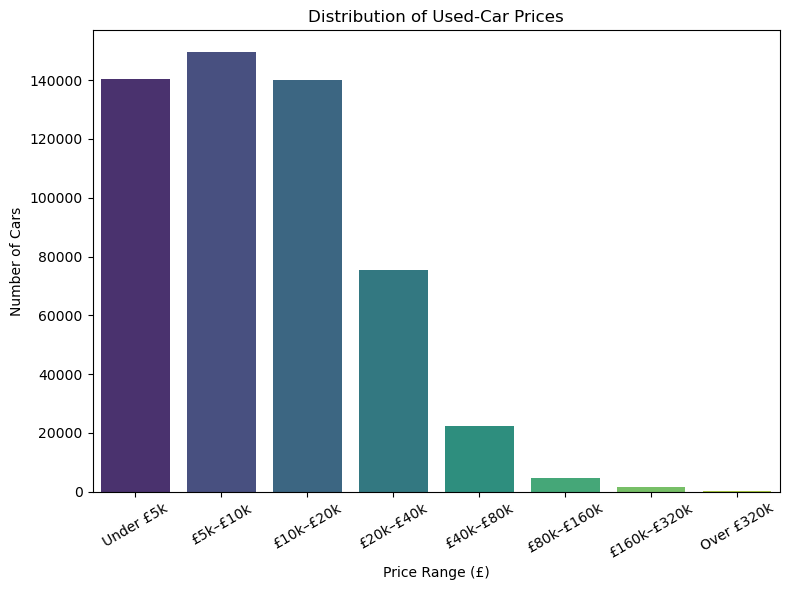

In [3]:
# Price Distribution Visualization
bins = [0, 5000, 10000, 20000, 40000, 80000, 160000, 320000, df["price"].max()]
labels = [
    "Under £5k", 
    "£5k–£10k", 
    "£10k–£20k", 
    "£20k–£40k", 
    "£40k–£80k", 
    "£80k–£160k", 
    "£160k–£320k", 
    "Over £320k"
]

df["price_range"] = pd.cut(df["price"], bins=bins, labels=labels, include_lowest=True)


plt.figure(figsize=(8,6))
order = df["price_range"].value_counts().sort_index(ascending=True)

sns.barplot(
    x=order.index,
    y=order.values,
    hue=order.index,          
    legend=False,            
    palette="viridis"
)

plt.xlabel("Price Range (£)")
plt.ylabel("Number of Cars")
plt.title("Distribution of Used-Car Prices")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


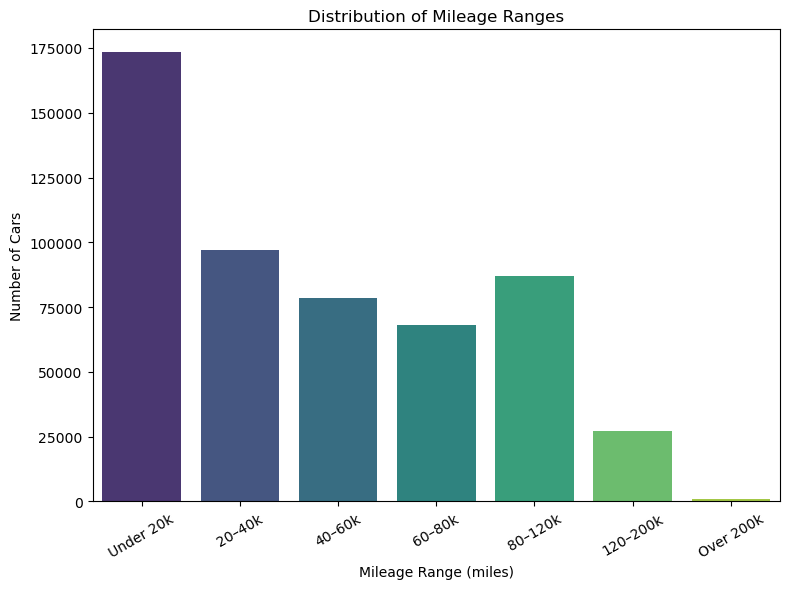

In [4]:
# Mileage Distribution Visualization
mile_bins = [0, 20000, 40000, 60000, 80000, 120000, 200000, df["mileage"].max()]

mile_labels = [
    "Under 20k",
    "20–40k",
    "40–60k",
    "60–80k",
    "80–120k",
    "120–200k",
    "Over 200k"
]

df["mileage_range"] = pd.cut(
    df["mileage"], bins=mile_bins, labels=mile_labels, include_lowest=True
)

order = df["mileage_range"].value_counts().reindex(mile_labels)

plt.figure(figsize=(8,6))
sns.barplot(
    x=order.index,
    y=order.values,
    hue=order.index,
    legend=False,
    palette="viridis"
)
plt.xlabel("Mileage Range (miles)")
plt.ylabel("Number of Cars")
plt.title("Distribution of Mileage Ranges")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

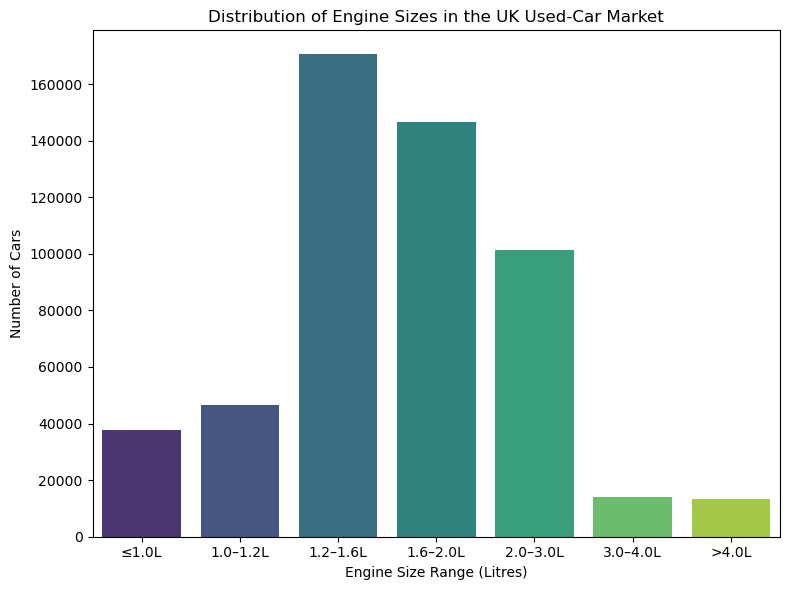

In [5]:
# Engine Size Distribution Visualization
engine_bins = [0, 1.0, 1.2, 1.6, 2.0, 3.0, 4.0, df["engine_size"].max()]
engine_labels = [
    "≤1.0L",
    "1.0–1.2L",
    "1.2–1.6L",
    "1.6–2.0L",
    "2.0–3.0L",
    "3.0–4.0L",
    ">4.0L"
]

# Categorize into bins
df["engine_range"] = pd.cut(df["engine_size"], bins=engine_bins, labels=engine_labels, include_lowest=True)

# Count per range
order = df["engine_range"].value_counts().reindex(engine_labels)

plt.figure(figsize=(8,6))
sns.barplot(
    x=order.index,
    y=order.values,
    hue=order.index,
    legend=False,
    palette="viridis"
)
plt.xlabel("Engine Size Range (Litres)")
plt.ylabel("Number of Cars")
plt.title("Distribution of Engine Sizes in the UK Used-Car Market")
plt.tight_layout()
plt.show()

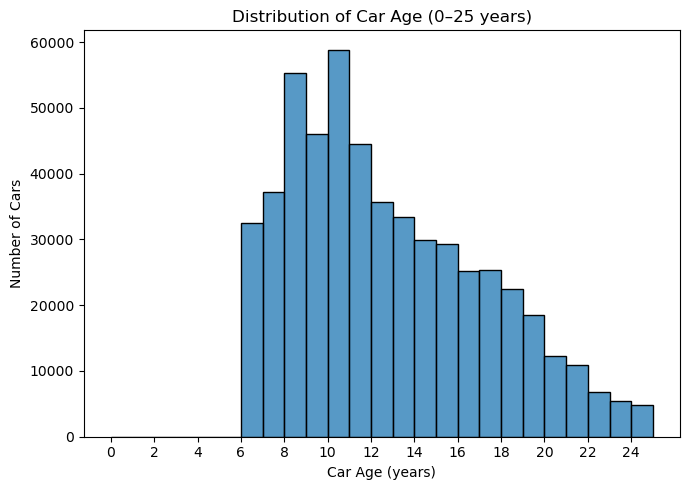

In [6]:
df_valid_age = df[(df["car_age"] >= 0) & (df["car_age"] <= 25)]

plt.figure(figsize=(7,5))
sns.histplot(
    df_valid_age["car_age"],
    bins=range(0, 26),     # 0–25 years
    kde=False
)

plt.xticks(range(0, 26, 2))
plt.xlabel("Car Age (years)")
plt.ylabel("Number of Cars")
plt.title("Distribution of Car Age (0–25 years)")
plt.tight_layout()
plt.show()

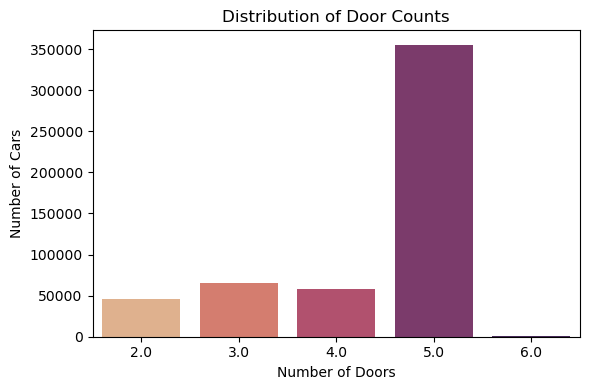

In [7]:
# distribution of door counts
df_valid_doors = df[df["door_num"].between(1, 6)]

plt.figure(figsize=(6,4))
sns.countplot(
    x="door_num",
    hue="door_num",
    data=df_valid_doors,
    legend=False,
    palette="flare"
)
plt.xlabel("Number of Doors")
plt.ylabel("Number of Cars")
plt.title("Distribution of Door Counts")
plt.tight_layout()
plt.show()

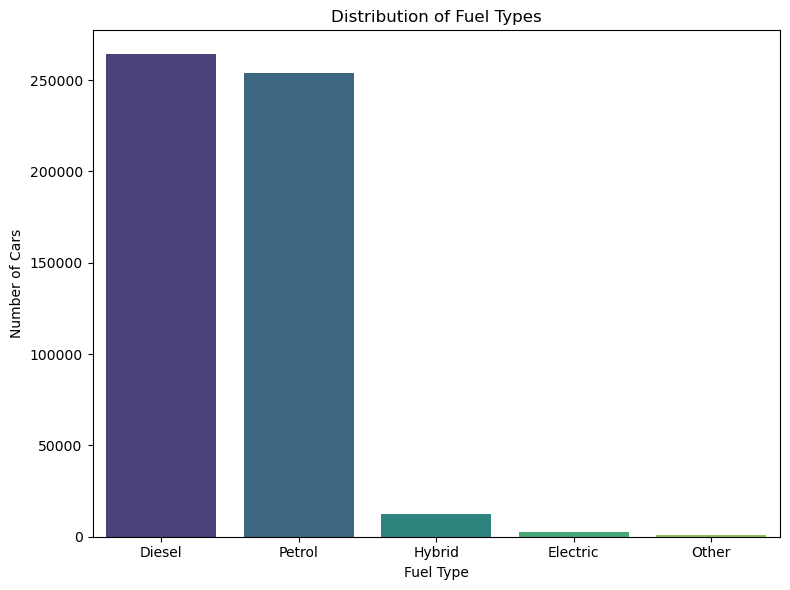

In [8]:
# distribution of fuel types
fuel_counts = df["fuel_type_clean"].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(
    x=fuel_counts.index,
    y=fuel_counts.values,
    hue=fuel_counts.index,
    legend=False,
    palette="viridis"
)
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.title("Distribution of Fuel Types")
plt.tight_layout()
plt.show()

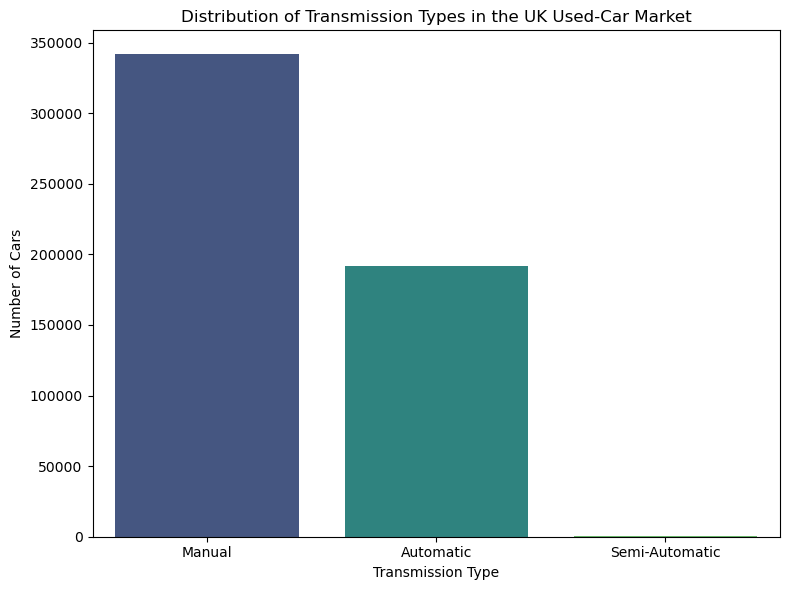

In [9]:
# distribution of transmission types
gear_counts = df["gearbox"].value_counts(dropna=True)

plt.figure(figsize=(8,6))
sns.barplot(
    x=gear_counts.index,
    y=gear_counts.values,
    hue=gear_counts.index,
    legend=False,
    palette="viridis"
)
plt.xlabel("Transmission Type")
plt.ylabel("Number of Cars")
plt.title("Distribution of Transmission Types in the UK Used-Car Market")
plt.tight_layout()
plt.show()

In [10]:
# distribution of body types
body_counts = df["bodytype_clean"].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(
    x=body_counts.index,
    y=body_counts.values,
    hue=body_counts.index,
    legend=False,
    palette="viridis"
)
plt.xlabel("Body Type")
plt.ylabel("Number of Cars")
plt.title("Distribution of Body Types in the UK Used-Car Market")
plt.tight_layout()
plt.show()

KeyError: 'bodytype_clean'

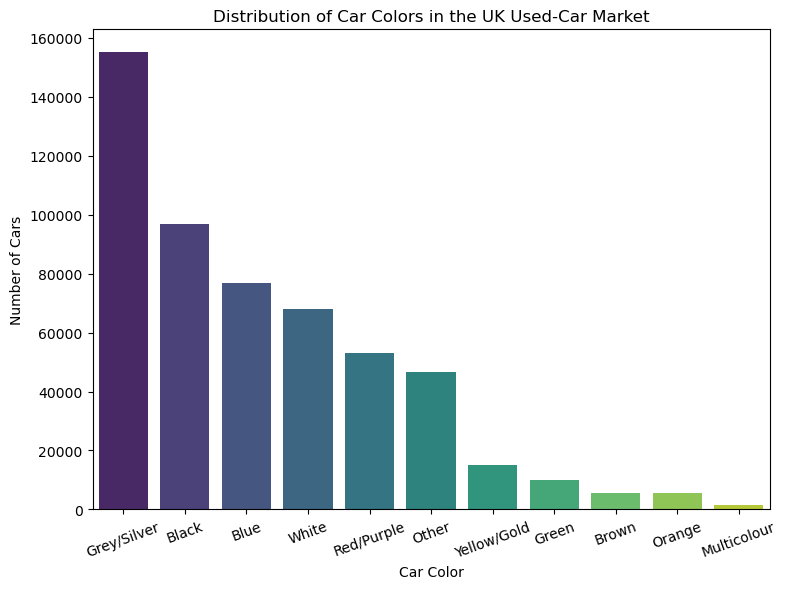

In [ ]:
# distribution of car colors
color_counts = df["color_clean"].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(
    x=color_counts.index,
    y=color_counts.values,
    hue=color_counts.index,
    legend=False,
    palette="viridis"
)

plt.xlabel("Car Color")
plt.ylabel("Number of Cars")
plt.title("Distribution of Car Colors in the UK Used-Car Market")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

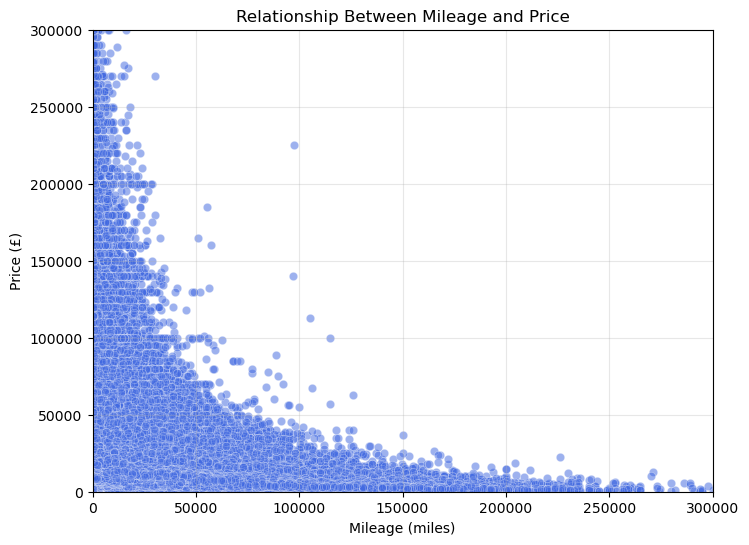

In [ ]:
# relationship between mileage and price
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="mileage",
    y="price",
    data=df,
    alpha=0.3,
    color="royalblue"
)

plt.xlim(0, 300000)
plt.ylim(0, 300000)

plt.xlabel("Mileage (miles)")
plt.ylabel("Price (£)")
plt.title("Relationship Between Mileage and Price")
plt.grid(alpha=0.3)
plt.show()

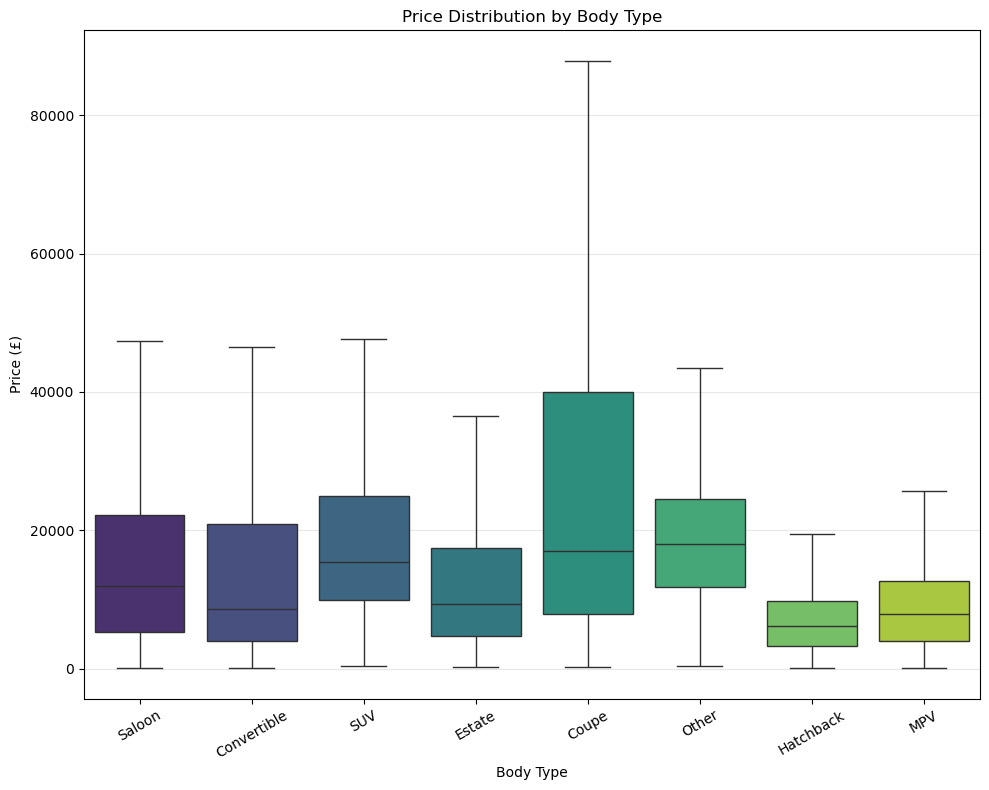

In [ ]:
plt.figure(figsize=(10,8))
sns.boxplot(
    x="bodytype_clean",
    y="price",
    data=df,
    hue="bodytype_clean", 
    legend=False,
    showfliers=False,
    palette="viridis"
)

plt.xlabel("Body Type")
plt.ylabel("Price (£)")
plt.title("Price Distribution by Body Type")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

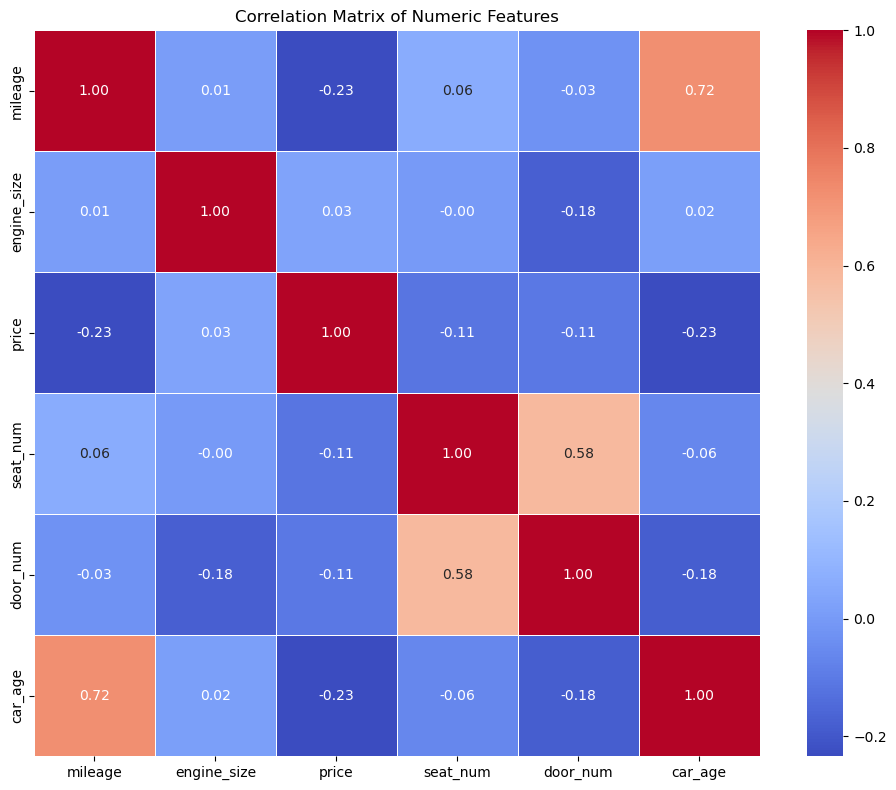

In [ ]:
# Select numeric columns only
numeric_cols = df.select_dtypes(include=["float64", "int64", "Int64"]).columns

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()
